In [2]:
# Cell 1: Setup and Library Imports

# Import libraries for data processing, visualization, and machine learning
# - pandas: For DataFrame operations (loading CSVs in Cell 2)
# - numpy: For numerical computations (replacing infinites in Cell 4)
# - matplotlib, seaborn: For plotting (histograms, heatmap in Cell 6)
# - sklearn.preprocessing: For StandardScaler (data scaling, may be used later)
# - sklearn.model_selection: For train_test_split (data splitting, may be used later)
# - imblearn.over_sampling: For SMOTE (class balancing, may be used later)
# - tensorflow: For neural network models (matches Colab version 2.18.0, may be used in later cells)
# - os: For file path operations (local paths in Cell 2)
# - warnings: To suppress non-critical warnings for cleaner output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import os
import warnings
import joblib
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Verify TensorFlow version to ensure compatibility
# - Should be 2.18.0, matching Colab setup
# - Confirms resolution of msvcp140_1.dll error
print("TensorFlow Version:", tf.__version__)

# Check GPU availability
# - Expect [] for CPU-only setup (like Colab, no GPU configured)
# - If GPU is added later, install tensorflow-gpu and CUDA/cuDNN
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Set random seed for reproducibility
# - Ensures consistent results for train_test_split, SMOTE, etc.
# - Matches Colab setup (seed 42)
np.random.seed(42)
tf.random.set_seed(42)

# Verify dataset path exists
# - Uses relative path ./CICIDS2017/ (assumes CICIDS2017 folder is in D:\Documents\Projects\DeepGuard)
# - os.path ensures Windows-compatible paths (\)
# - Raises error if folder is missing to catch issues early
dataset_path = "../CICIDS2017/"
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset path {dataset_path} does not exist. Ensure CICIDS2017 folder contains all CSVs.")
else:
    print(f"Dataset path verified: {dataset_path}")

TensorFlow Version: 2.18.0
GPU Available: []
Dataset path verified: ../CICIDS2017/


In [5]:
# Cell 2: Load and Combine Dataset

# Define dataset path and CSV files
# - Uses local path ./CICIDS2017/ (not Google Drive)
# - Lists all eight CICIDS2017 CSVs, matching Colab setup
# - os.path.join ensures Windows-compatible paths (\)
dataset_path = "../CICIDS2017/"
csv_files = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
]

# Load and combine CSVs into a single DataFrame
# - Reads each CSV with pandas, appends to a list, then concatenates
# - low_memory=False handles large files (~2.8M rows total)
# - Error handling catches missing files or parsing errors
# - Prints shape of each file for verification
dfs = []
for file in csv_files:
    try:
        df = pd.read_csv(os.path.join(dataset_path, file), low_memory=False)
        dfs.append(df)
        print(f"Loaded {file}: {df.shape}")
    except Exception as e:
        print(f"Error loading {file}: {e}")
combined_df = pd.concat(dfs, ignore_index=True)

# Display basic dataset information
# - Shape: Confirms total rows (~2.8M) and columns
# - Columns: Lists all column names for debugging (e.g., KeyError issues)
# - Sample data: Shows first few rows to verify data integrity
print("\nCombined Dataset Shape:", combined_df.shape)
print("Columns:\n", combined_df.columns.tolist())
print("\nSample Data:\n", combined_df.head())

Loaded Monday-WorkingHours.pcap_ISCX.csv: (529918, 79)
Loaded Tuesday-WorkingHours.pcap_ISCX.csv: (445909, 79)
Loaded Wednesday-workingHours.pcap_ISCX.csv: (692703, 79)
Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (170366, 79)
Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (288602, 79)
Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: (191033, 79)
Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (286467, 79)
Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 79)

Combined Dataset Shape: (2830743, 79)
Columns:
 [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Fl

In [6]:
combined_df.columns = combined_df.columns.str.strip().str.replace('�', '').str.replace(' ', '_').str.lower()
print("Cleaned Columns:\n", combined_df.columns.tolist())

Cleaned Columns:
 ['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std', 'bwd_packet_length_max', 'bwd_packet_length_min', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_bytes/s', 'flow_packets/s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length', 'bwd_header_length', 'fwd_packets/s', 'bwd_packets/s', 'min_packet_length', 'max_packet_length', 'packet_length_mean', 'packet_length_std', 'packet_length_variance', 'fin_flag_count', 'syn_flag_count', 'rst_flag_count', 'psh_flag_count', 'ack_flag_count', 'urg_flag_count', 'cwe_flag_count

In [7]:

combined_df = combined_df.replace([np.inf, -np.inf], np.nan)


combined_df = combined_df.dropna()
print("Shape after dropping NaN:", combined_df.shape)


combined_df = combined_df.drop_duplicates()
print("Shape after removing duplicates:", combined_df.shape)


numerical_cols = combined_df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if col in ['flow_duration', 'total_fwd_packets', 'total_backward_packets',
               'total_length_of_fwd_packets', 'total_length_of_bwd_packets']:
        invalid_rows = combined_df[combined_df[col] < 0]
        if not invalid_rows.empty:
            print(f"Found {len(invalid_rows)} rows with negative values in {col}")
            combined_df = combined_df[combined_df[col] >= 0]
print("Shape after validating numerical columns:", combined_df.shape)


for col in numerical_cols:
    non_numeric = combined_df[col].apply(lambda x: not isinstance(x, (int, float)))
    if non_numeric.any():
        print(f"Non-numeric values found in {col}:\n", combined_df[non_numeric][col].head())

Shape after dropping NaN: (2827876, 79)
Shape after removing duplicates: (2520798, 79)
Found 107 rows with negative values in flow_duration
Shape after validating numerical columns: (2520691, 79)



Unique values in 'label':
 label
BENIGN                        2094950
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Encoded Multi-Class Label Distribution:
 multi_label
0     2094950
4      172846
2      128014
10      90694
3       10286
7        5931
6        5385
5        5228
11       3219
1        1948
12       1470
14        652
9          36
13         21
8          11
Name: count, dtype: int64
Label encoder saved as 'label_encoder.pkl'.


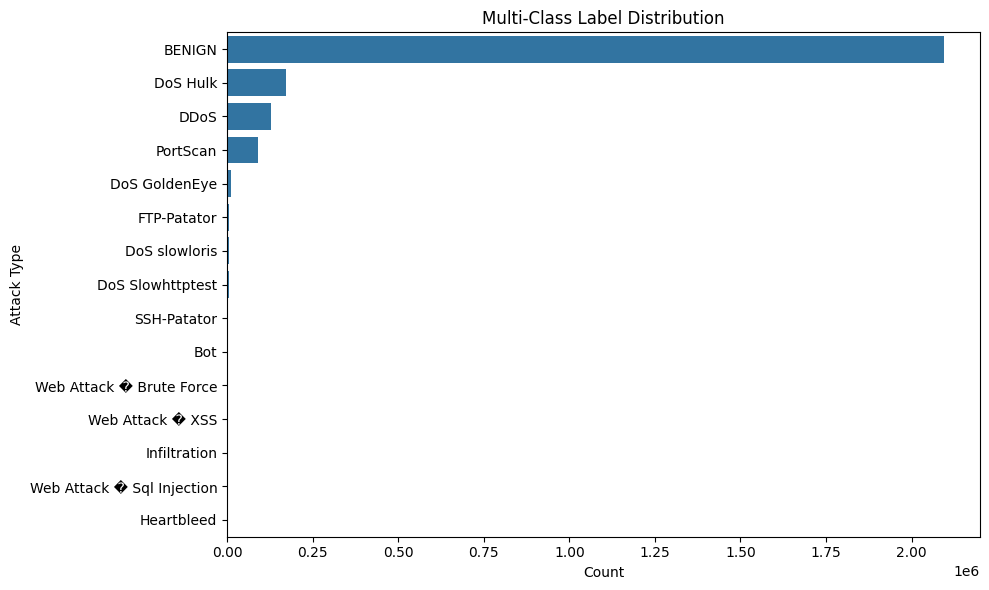

In [8]:
label_column = 'label'

# Check unique values in the label column
print("\nUnique values in 'label':\n", combined_df[label_column].value_counts())

# Verify that the label column exists and has valid data
if label_column not in combined_df.columns:
    raise ValueError(f"Label column '{label_column}' not found in DataFrame.")
if combined_df[label_column].isnull().any():
    raise ValueError("Label column contains NaN values. Please handle missing values before encoding.")

# Encode the multi-class labels
label_encoder = LabelEncoder()
combined_df['multi_label'] = label_encoder.fit_transform(combined_df[label_column])
print("\nEncoded Multi-Class Label Distribution:\n", combined_df['multi_label'].value_counts())

# Save the label encoder for later use (e.g., decoding predictions)
joblib.dump(label_encoder, 'label_encoder.pkl')
print("Label encoder saved as 'label_encoder.pkl'.")

# Visualize the multi-class label distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='label', data=combined_df, order=combined_df['label'].value_counts().index)
plt.title('Multi-Class Label Distribution')
plt.xlabel('Count')
plt.ylabel('Attack Type')
plt.tight_layout()
plt.show()

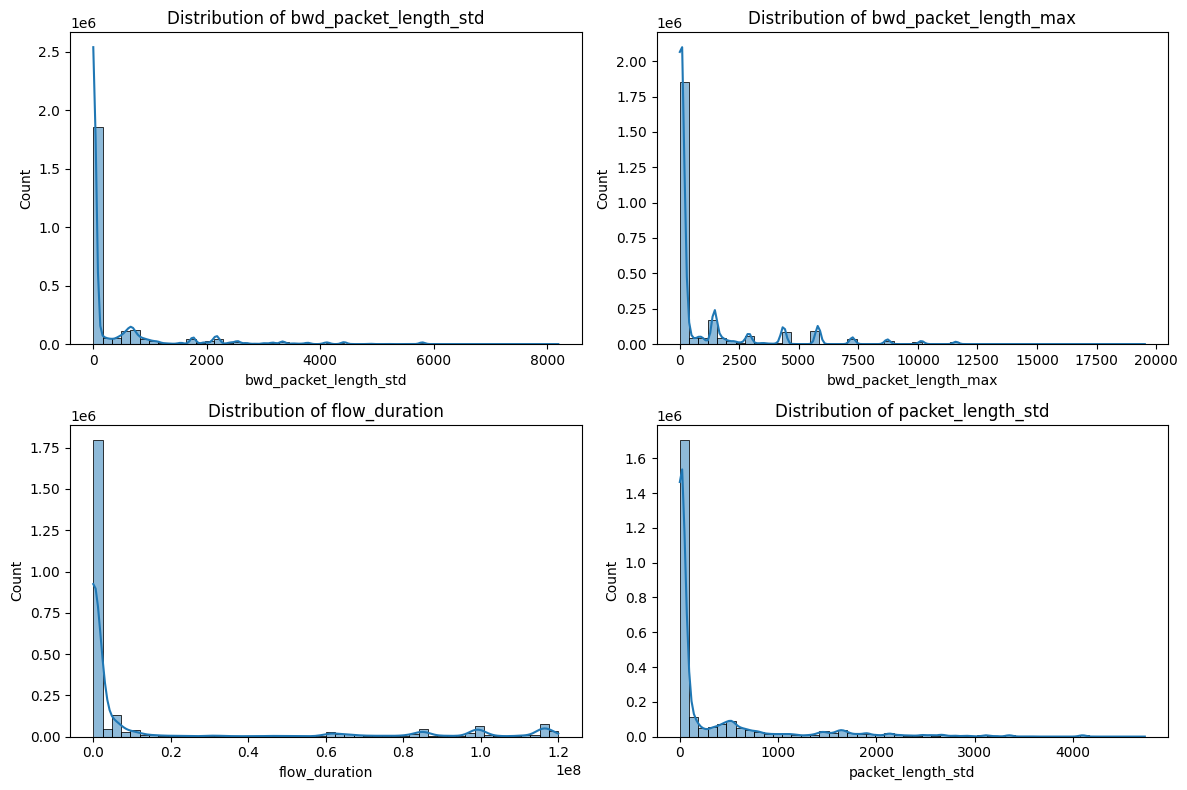

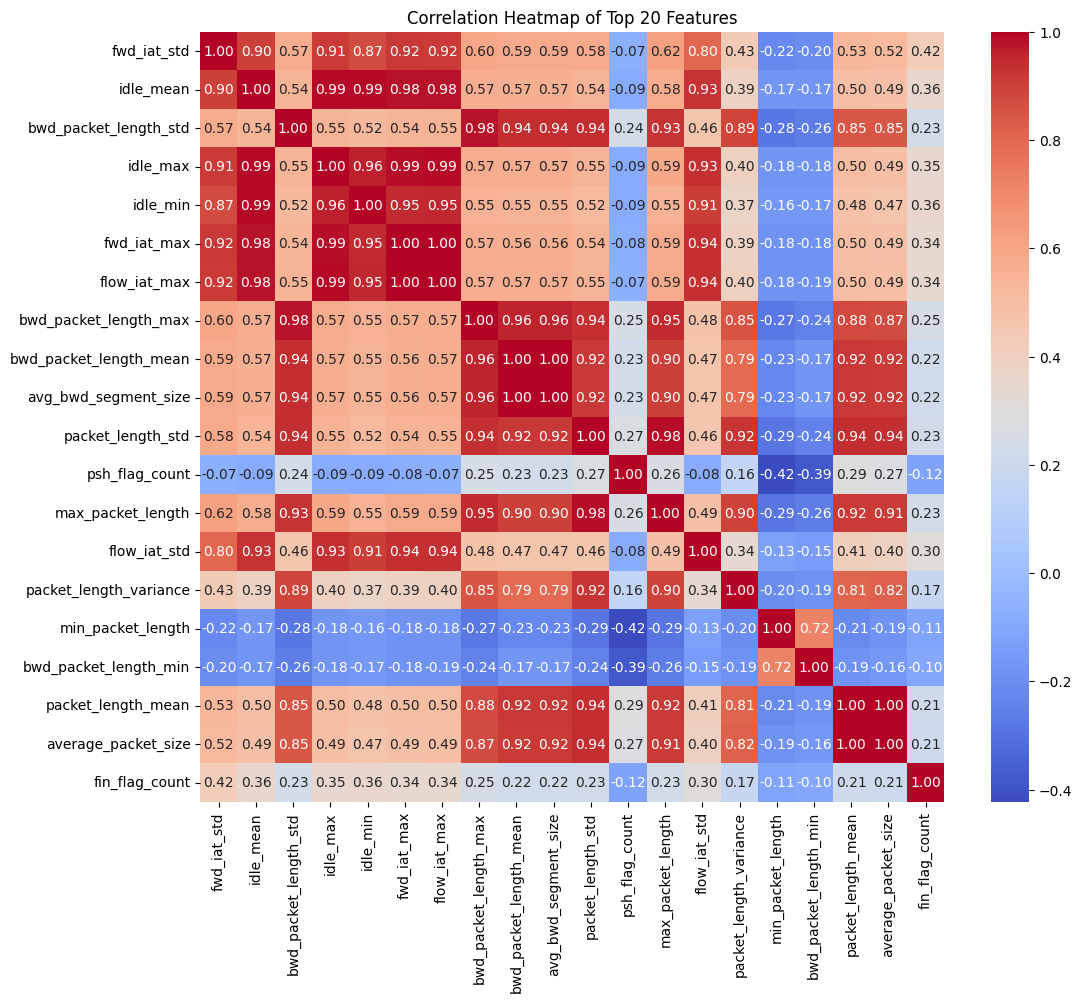

In [9]:
# Select numerical columns excluding the label
numerical_cols = [col for col in combined_df.select_dtypes(include=[np.number]).columns if col != 'multi_label']

# Plot histograms for top features
top_features = ['bwd_packet_length_std', 'bwd_packet_length_max', 'flow_duration', 'packet_length_std']
plt.figure(figsize=(12, 8))
for i, col in enumerate(top_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(combined_df[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Correlation heatmap for top 20 features
top_corr_features = combined_df[numerical_cols + ['multi_label']].corr()['multi_label'].abs().sort_values(ascending=False).index[1:21]
plt.figure(figsize=(12, 10))
sns.heatmap(combined_df[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Top 20 Features')
plt.show()

In [10]:
# Check for outliers in top features using IQR
for col in top_features:
    Q1 = combined_df[col].quantile(0.25)
    Q3 = combined_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = combined_df[(combined_df[col] < Q1 - 1.5 * IQR) | (combined_df[col] > Q3 + 1.5 * IQR)]
    print(f"Outliers in {col}: {len(outliers)}")

Outliers in bwd_packet_length_std: 442300
Outliers in bwd_packet_length_max: 374533
Outliers in flow_duration: 468192
Outliers in packet_length_std: 330260


In [11]:
# Define domain-knowledge features
domain_features = [
    'destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets',
    'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max',
    'bwd_packet_length_max', 'flow_bytes/s', 'flow_packets/s', 'flow_iat_mean',
    'fwd_iat_total', 'bwd_iat_total', 'fwd_psh_flags', 'syn_flag_count',  
    'packet_length_mean', 'init_win_bytes_forward', 'init_win_bytes_backward',
    'act_data_pkt_fwd', 'min_seg_size_forward'
]

# Select top correlated features
corr_features = combined_df[numerical_cols + ['multi_label']].corr()['multi_label'].abs().sort_values(ascending=False).index[1:21].tolist()

# Combine domain and correlated features
selected_features = list(set(domain_features + corr_features))  

# Verify all selected features exist
missing_features = [f for f in selected_features if f not in combined_df.columns]
if missing_features:
    raise ValueError(f"Features not found in combined_df: {missing_features}")
print("\nSelected Features:\n", selected_features)


Selected Features:
 ['packet_length_variance', 'flow_packets/s', 'bwd_packet_length_min', 'fwd_iat_std', 'psh_flag_count', 'total_fwd_packets', 'total_length_of_fwd_packets', 'fwd_iat_max', 'idle_max', 'fwd_iat_total', 'flow_bytes/s', 'bwd_packet_length_mean', 'packet_length_std', 'fwd_psh_flags', 'idle_min', 'flow_duration', 'total_backward_packets', 'total_length_of_bwd_packets', 'fin_flag_count', 'flow_iat_std', 'syn_flag_count', 'act_data_pkt_fwd', 'packet_length_mean', 'bwd_iat_total', 'min_seg_size_forward', 'max_packet_length', 'fwd_packet_length_max', 'avg_bwd_segment_size', 'destination_port', 'flow_iat_mean', 'idle_mean', 'min_packet_length', 'bwd_packet_length_max', 'init_win_bytes_backward', 'init_win_bytes_forward', 'bwd_packet_length_std', 'average_packet_size', 'flow_iat_max']


In [12]:
# Apply log transformation to skewed features
skewed_features = ['flow_duration', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets']
for col in skewed_features:
    if col in selected_features:
        combined_df[f'log_{col}'] = np.log1p(combined_df[col])  
        selected_features.append(f'log_{col}')
        selected_features.remove(col)  
print("\nUpdated Features after Transformation:\n", selected_features)

# Add packet rate features
combined_df['fwd_packet_rate'] = combined_df['total_fwd_packets'] / (combined_df['flow_duration'] + 1e-6)
combined_df['bwd_packet_rate'] = combined_df['total_backward_packets'] / (combined_df['flow_duration'] + 1e-6)
selected_features.extend(['fwd_packet_rate', 'bwd_packet_rate'])
print("\nFinal Features:\n", selected_features)


Updated Features after Transformation:
 ['packet_length_variance', 'flow_packets/s', 'bwd_packet_length_min', 'fwd_iat_std', 'psh_flag_count', 'total_fwd_packets', 'fwd_iat_max', 'idle_max', 'fwd_iat_total', 'flow_bytes/s', 'bwd_packet_length_mean', 'packet_length_std', 'fwd_psh_flags', 'idle_min', 'total_backward_packets', 'fin_flag_count', 'flow_iat_std', 'syn_flag_count', 'act_data_pkt_fwd', 'packet_length_mean', 'bwd_iat_total', 'min_seg_size_forward', 'max_packet_length', 'fwd_packet_length_max', 'avg_bwd_segment_size', 'destination_port', 'flow_iat_mean', 'idle_mean', 'min_packet_length', 'bwd_packet_length_max', 'init_win_bytes_backward', 'init_win_bytes_forward', 'bwd_packet_length_std', 'average_packet_size', 'flow_iat_max', 'log_flow_duration', 'log_total_length_of_fwd_packets', 'log_total_length_of_bwd_packets']

Final Features:
 ['packet_length_variance', 'flow_packets/s', 'bwd_packet_length_min', 'fwd_iat_std', 'psh_flag_count', 'total_fwd_packets', 'fwd_iat_max', 'idle_m

In [13]:
# Scale selected features
scaler = StandardScaler()
X = combined_df[selected_features]
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features, index=X.index)
print("\nScaled Features Statistics:\n", X_scaled_df.describe().round(2))


Scaled Features Statistics:
        packet_length_variance  flow_packets/s  bwd_packet_length_min  \
count              2520691.00      2520691.00             2520691.00   
mean                    -0.00           -0.00                  -0.00   
std                      1.00            1.00                   1.00   
min                     -0.31           -0.23                  -0.61   
25%                     -0.31           -0.23                  -0.61   
50%                     -0.31           -0.23                  -0.61   
75%                     -0.25           -0.15                   0.55   
max                     12.59           19.55                  40.25   

       fwd_iat_std  psh_flag_count  total_fwd_packets  fwd_iat_max  \
count   2520691.00      2520691.00         2520691.00   2520691.00   
mean         -0.00           -0.00              -0.00         0.00   
std           1.00            1.00               1.00         1.00   
min          -0.36           -0.65       


Shape after SMOTE: (31424250, 40)
Balanced Multi-Class Label Distribution:
 multi_label
0     2094950
7     2094950
11    2094950
6     2094950
5     2094950
4     2094950
3     2094950
8     2094950
12    2094950
14    2094950
13    2094950
9     2094950
1     2094950
10    2094950
2     2094950
Name: count, dtype: int64


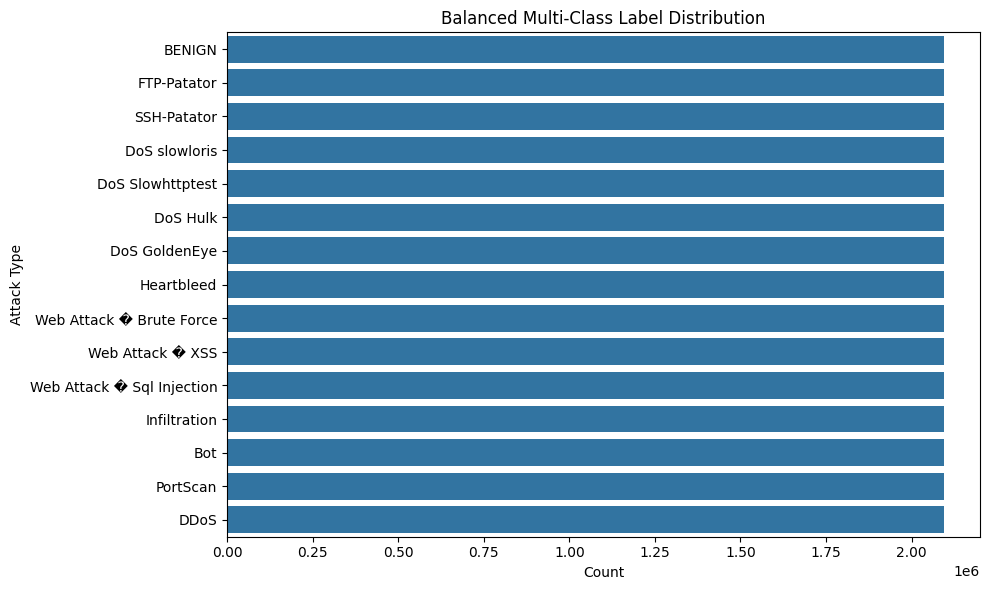

In [14]:
# Apply SMOTE for multi-class balancing
y = combined_df['multi_label']
smote = SMOTE(random_state=42, k_neighbors=5)  # Adjust k_neighbors for small classes
X_balanced, y_balanced = smote.fit_resample(X_scaled_df, y)
print("\nShape after SMOTE:", X_balanced.shape)
print("Balanced Multi-Class Label Distribution:\n", pd.Series(y_balanced).value_counts())

# Visualize balanced multi-class distribution
plt.figure(figsize=(10, 6))
sns.countplot(y=pd.Series(label_encoder.inverse_transform(y_balanced)), order=pd.Series(label_encoder.inverse_transform(y_balanced)).value_counts().index)
plt.title('Balanced Multi-Class Label Distribution')
plt.xlabel('Count')
plt.ylabel('Attack Type')
plt.tight_layout()
plt.show()

In [15]:
# Perform train-test split for multi-class
X_train, X_temp, y_train, y_temp = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Print shapes
print("\nTrain Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

# Print train label distribution using encoded labels to avoid memory-intensive inverse transform
print("Train Label Distribution (Encoded):")
unique_labels, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique_labels, counts):
    print(f"Label {label}: {count}")

# Optionally print decoded labels for a small sample to verify mapping
sample_size = min(1000, len(y_train))  # Use a small sample to avoid memory issues
sample_labels = label_encoder.inverse_transform(y_train[:sample_size])
print("\nSample Decoded Label Distribution (First 1000 samples):")
unique_sample_labels, sample_counts = np.unique(sample_labels, return_counts=True)
for label, count in zip(unique_sample_labels, sample_counts):
    print(f"{label}: {count}")


Train Shape: (21996975, 40)
Validation Shape: (4713637, 40)
Test Shape: (4713638, 40)
Train Label Distribution (Encoded):
Label 0: 1466465
Label 1: 1466465
Label 2: 1466465
Label 3: 1466465
Label 4: 1466465
Label 5: 1466465
Label 6: 1466465
Label 7: 1466465
Label 8: 1466465
Label 9: 1466465
Label 10: 1466465
Label 11: 1466465
Label 12: 1466465
Label 13: 1466465
Label 14: 1466465

Sample Decoded Label Distribution (First 1000 samples):
BENIGN: 66
Bot: 60
DDoS: 56
DoS GoldenEye: 76
DoS Hulk: 62
DoS Slowhttptest: 68
DoS slowloris: 67
FTP-Patator: 69
Heartbleed: 62
Infiltration: 65
PortScan: 65
SSH-Patator: 71
Web Attack � Brute Force: 58
Web Attack � Sql Injection: 75
Web Attack � XSS: 80


In [ ]:
# Save preprocessed datasets with multi-class labels
pd.concat([X_train, pd.Series(y_train, name='multi_label')], axis=1).to_csv('train.csv', index=False)
pd.concat([X_val, pd.Series(y_val, name='multi_label')], axis=1).to_csv('val.csv', index=False)
pd.concat([X_test, pd.Series(y_test, name='multi_label')], axis=1).to_csv('test.csv', index=False)

# Save scaler
joblib.dump(scaler, 'scaler.pkl')
print("Preprocessed data and scaler saved successfully.")